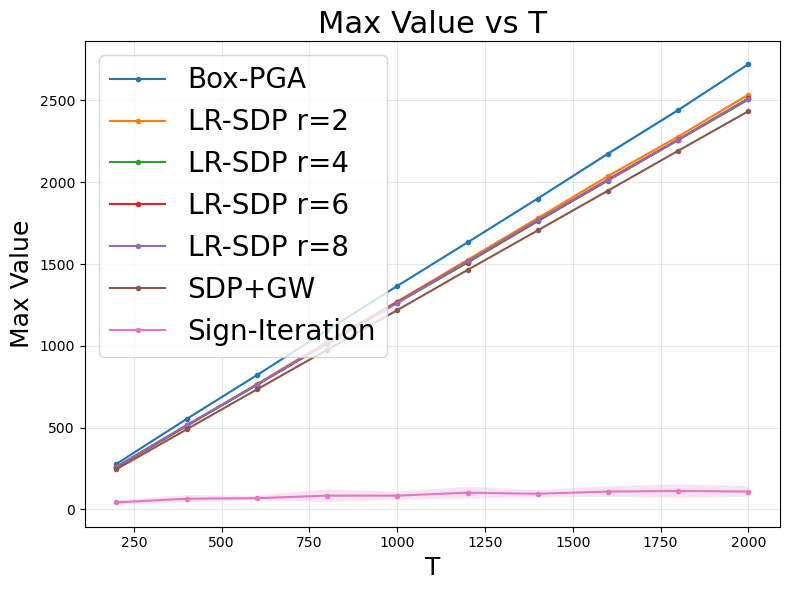

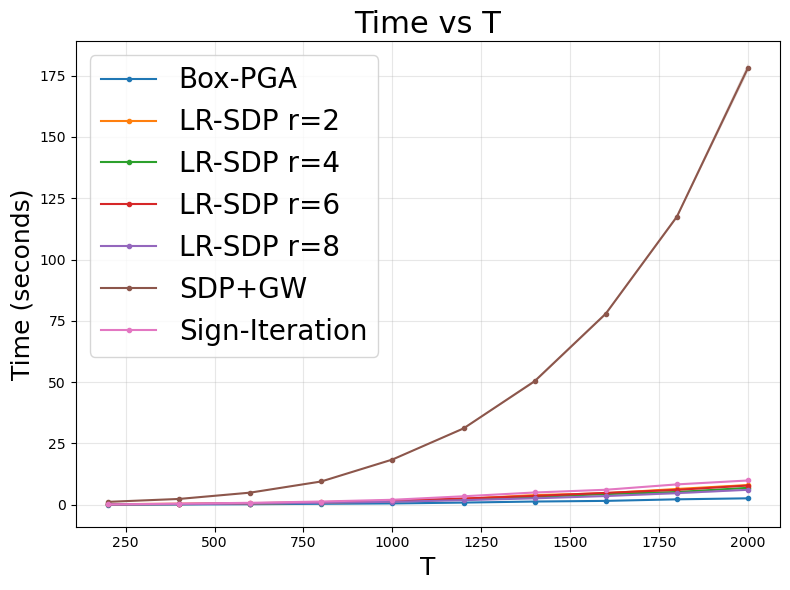

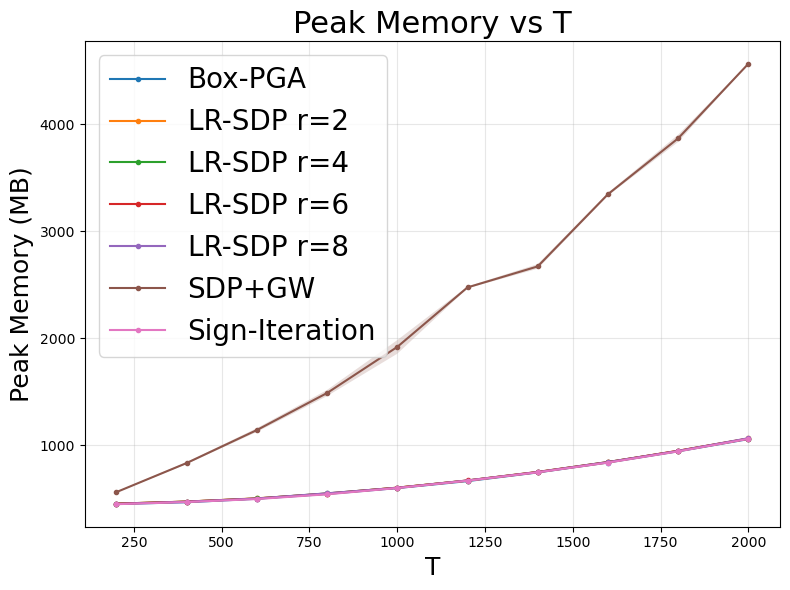

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("summary.csv")

# Optional: make method labels include rank when rank exists
df["label"] = df.apply(
    lambda row: f"{row['method']} r={int(row['rank'])}"
    if pd.notna(row["rank"]) and "r=" not in str(row["method"])
    else row["method"],
    axis=1,
)

def plot_mean_std(
    df,
    x_col,
    mean_col,
    std_col,
    ylabel,
    title,
    output_name=None,
):
    plt.figure(figsize=(8,6))

    for label, group in df.groupby("label"):
        group = group.sort_values(x_col)

        x = group[x_col]
        mean = group[mean_col]
        std = group[std_col]

        plt.plot(x, mean, marker="o", markersize=3, label=label)
        plt.fill_between(
            x,
            mean - std,
            mean + std,
            alpha=0.2,
        )

    plt.xlabel("T", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.title(title, fontsize=22)
    plt.legend(fontsize=20)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if output_name is not None:
        plt.savefig(output_name, dpi=300, bbox_inches="tight")

    plt.show()


# 1. max_value vs T
plot_mean_std(
    df=df,
    x_col="T",
    mean_col="max_value_mean",
    std_col="max_value_std",
    ylabel="Max Value",
    title="Max Value vs T",
    output_name="max_value_vs_T.png",
)

# 2. time vs T
plot_mean_std(
    df=df,
    x_col="T",
    mean_col="time_seconds_mean",
    std_col="time_seconds_std",
    ylabel="Time (seconds)",
    title="Time vs T",
    output_name="time_vs_T.png",
)

# 3. peak memory vs T
plot_mean_std(
    df=df,
    x_col="T",
    mean_col="peak_memory_mb_mean",
    std_col="peak_memory_mb_std",
    ylabel="Peak Memory (MB)",
    title="Peak Memory vs T",
    output_name="peak_memory_vs_T.png",
)